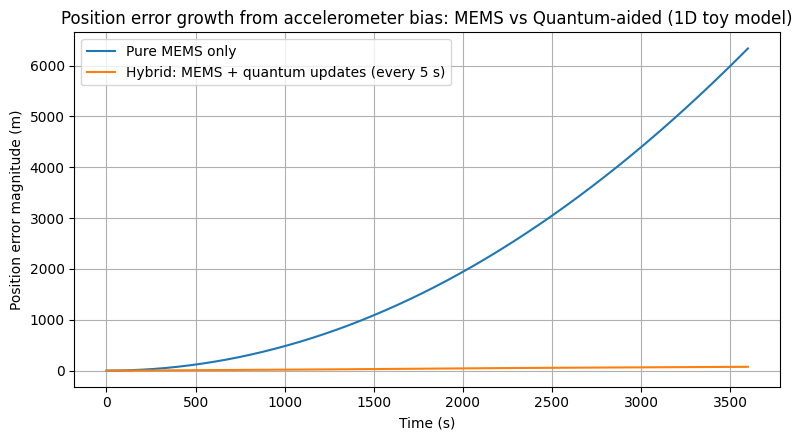

In [1]:
# Quick simulation: position error growth from MEMS bias vs. quantum-aided hybrid
# (toy model to build intuition; not a detailed nav filter)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# Simulation parameters
T_total = 3600  # seconds (1 hour)
dt = 0.01       # 100 Hz integration
N = int(T_total/dt)
t = np.arange(N)*dt

# True motion: zero acceleration/velocity/position (hovering platform)
a_true = np.zeros(N)

g = 9.80665

# MEMS accelerometer characteristics (toy numbers)
bias_mems = 100e-6 * g      # 100 micro-g bias
noise_mems = 50e-6 * g      # 50 micro-g/√Hz white noise spectral density approx per-sample std
sigma_mems = noise_mems/np.sqrt(dt)

# Quantum sensor update characteristics (toy numbers)
update_period = 5.0  # seconds between atom-interferometer updates
update_steps = int(update_period/dt)
sigma_quant = 2e-6 * g      # residual after update ~2 micro-g

# Helper to integrate acceleration to position (strapdown simplification: 1D)
def integrate_motion(a_meas):
    v = np.zeros_like(a_meas)
    x = np.zeros_like(a_meas)
    for k in range(1, len(a_meas)):
        v[k] = v[k-1] + a_meas[k]*dt
        x[k] = x[k-1] + v[k]*dt
    return x

# Case 1: Pure MEMS
a_mems = a_true + bias_mems + np.random.randn(N)*sigma_mems
x_mems = integrate_motion(a_mems)

# Case 2: Hybrid MEMS + quantum updates (dead-time aware bias correction)
bias_est = 0.0
a_hybrid = np.zeros(N)
mems_noise = np.random.randn(N)*sigma_mems
for k in range(N):
    # raw MEMS
    a_raw = a_true[k] + bias_mems + mems_noise[k]
    # apply current bias estimate
    a_hybrid[k] = a_raw - bias_est
    # quantum update every update_steps
    if k % update_steps == 0 and k > 0:
        # "measure" bias via quantum sensor (noisy estimate of true bias_mems)
        measured_bias = bias_mems + np.random.randn()*sigma_quant
        # simple correction (servo the DC component)
        bias_est = measured_bias

x_hybrid = integrate_motion(a_hybrid)

# Plot
plt.figure(figsize=(8,4.5))
plt.plot(t, np.abs(x_mems), label="Pure MEMS only")
plt.plot(t, np.abs(x_hybrid), label="Hybrid: MEMS + quantum updates (every 5 s)")
plt.xlabel("Time (s)")
plt.ylabel("Position error magnitude (m)")
plt.title("Position error growth from accelerometer bias: MEMS vs Quantum-aided (1D toy model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

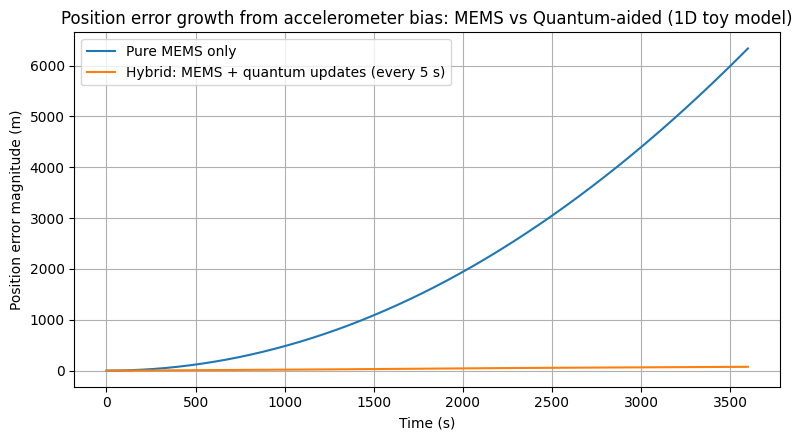

In [2]:
# Quick simulation: position error growth from MEMS bias vs. quantum-aided hybrid
# (toy model to build intuition; not a detailed nav filter)
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for plotting

np.random.seed(7)  # Set random seed for reproducibility

# Simulation parameters
T_total = 3600  # seconds (1 hour) - total simulation time
dt = 0.01       # 100 Hz integration - time step for simulation
N = int(T_total/dt)  # Number of simulation steps
t = np.arange(N)*dt  # Time array for each step

# True motion: zero acceleration/velocity/position (hovering platform)
a_true = np.zeros(N)  # True acceleration is zero throughout

g = 9.80665  # Standard gravity in m/s^2

# MEMS accelerometer characteristics (toy numbers)
bias_mems = 100e-6 * g      # 100 micro-g bias (constant offset error)
noise_mems = 50e-6 * g      # 50 micro-g/√Hz white noise spectral density
sigma_mems = noise_mems/np.sqrt(dt)  # Convert noise spectral density to per-sample std

# Quantum sensor update characteristics (toy numbers)
update_period = 5.0  # seconds between atom-interferometer updates
update_steps = int(update_period/dt)  # Number of steps between quantum updates
sigma_quant = 2e-6 * g      # Residual error after quantum update (~2 micro-g)

# Helper to integrate acceleration to position (strapdown simplification: 1D)
def integrate_motion(a_meas):
    v = np.zeros_like(a_meas)  # Initialize velocity array
    x = np.zeros_like(a_meas)  # Initialize position array
    for k in range(1, len(a_meas)):
        v[k] = v[k-1] + a_meas[k]*dt  # Integrate acceleration to velocity
        x[k] = x[k-1] + v[k]*dt       # Integrate velocity to position
    return x  # Return position array

# Case 1: Pure MEMS
a_mems = a_true + bias_mems + np.random.randn(N)*sigma_mems  # Simulate MEMS measurements with bias and noise
x_mems = integrate_motion(a_mems)  # Integrate MEMS acceleration to get position error

# Case 2: Hybrid MEMS + quantum updates (dead-time aware bias correction)
bias_est = 0.0  # Initial bias estimate
a_hybrid = np.zeros(N)  # Array to store hybrid acceleration measurements
mems_noise = np.random.randn(N)*sigma_mems  # Generate MEMS noise for all steps
for k in range(N):
    # raw MEMS
    a_raw = a_true[k] + bias_mems + mems_noise[k]  # MEMS measurement at step k
    # apply current bias estimate
    a_hybrid[k] = a_raw - bias_est  # Correct MEMS measurement using bias estimate
    # quantum update every update_steps
    if k % update_steps == 0 and k > 0:
        # "measure" bias via quantum sensor (noisy estimate of true bias_mems)
        measured_bias = bias_mems + np.random.randn()*sigma_quant  # Simulate quantum bias measurement
        # simple correction (servo the DC component)
        bias_est = measured_bias  # Update bias estimate with quantum measurement

x_hybrid = integrate_motion(a_hybrid)  # Integrate hybrid acceleration to get position error

# Plot
plt.figure(figsize=(8,4.5))  # Create a new figure for plotting
plt.plot(t, np.abs(x_mems), label="Pure MEMS only")  # Plot position error for pure MEMS
plt.plot(t, np.abs(x_hybrid), label="Hybrid: MEMS + quantum updates (every 5 s)")  # Plot position error for hybrid
plt.xlabel("Time (s)")  # X-axis label
plt.ylabel("Position error magnitude (m)")  # Y-axis label
plt.title("Position error growth from accelerometer bias: MEMS vs Quantum-aided (1D toy model)")  # Plot title
plt.legend()  # Show legend
plt.grid(True)  # Show grid
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot